In [67]:

!pip install opendatasets --quiet
import opendatasets as od
dataset_url = 'https://www.kaggle.com/datasets/andrewmvd/animal-faces'
od.download(dataset_url)

Skipping, found downloaded files in "./animal-faces" (use force=True to force download)


In [68]:
import torch
import torchvision
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader,Dataset
import numpy as np
import pandas as pd
import torchvision.transforms as transforms
import os
from PIL import Image
from sklearn.preprocessing import LabelEncoder

device='cuda' if torch.cuda.is_available() else 'cpu'
print("Device Avalaible",device)

Device Avalaible cuda


In [69]:
image_path=[]
labels=[]
for i in os.listdir('/content/animal-faces/afhq'):
    for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
        for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
            image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
            labels.append(label)

df=pd.DataFrame(zip(image_path,labels),columns=['image_path','labels'])
df.head()


,image_path,labels
0,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
1,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
2,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
3,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
4,/content/animal-faces/afhq/val/dog/flickr_dog_...,dog


In [70]:
df['labels'].unique()

array(['dog', 'wild', 'cat'], dtype=object)

In [71]:
train=df.sample(frac=0.7)
test=df.drop(train.index)

val=test.sample(frac=0.5)
test=test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

(11291, 2)
(2420, 2)
(2419, 2)


In [72]:
label_encoder=LabelEncoder()

label_encoder.fit(df['labels'])


transform=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float32)
])


In [73]:
class CustomDataset(Dataset):
    def __init__(self,dataframe,transform=None):
        self.dataframe=dataframe
        self.transform=transform
        self.labels=torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)


    def __len__(self):
        return len(self.dataframe)


    def __getitem__(self,index):
      image_path=self.dataframe.iloc[index,0]
      label=self.labels[index]

      image=Image.open(image_path).convert('RGB')
      if self.transform:
        image=self.transform(image).to(device)

      return image,label



In [74]:
train_dataset=CustomDataset(dataframe=train,transform=transform)
val_dataset=CustomDataset(dataframe=val,transform=transform)
test_dataset=CustomDataset(dataframe=test,transform=transform)

In [75]:
train_dataset.__len__()

11291

In [76]:
train_dataset.__getitem__(2)

(tensor([[[0.2314, 0.2392, 0.2627,  ..., 0.4745, 0.4471, 0.4314],
          [0.2314, 0.2431, 0.2627,  ..., 0.4510, 0.4196, 0.3961],
          [0.2314, 0.2549, 0.2745,  ..., 0.4314, 0.4000, 0.3608],
          ...,
          [0.0824, 0.0902, 0.0902,  ..., 0.0980, 0.0980, 0.0941],
          [0.0824, 0.0863, 0.0824,  ..., 0.0980, 0.1020, 0.1020],
          [0.0824, 0.0824, 0.0824,  ..., 0.0980, 0.1020, 0.1020]],
 
         [[0.2157, 0.2157, 0.2314,  ..., 0.4275, 0.4118, 0.4000],
          [0.2157, 0.2196, 0.2314,  ..., 0.4039, 0.3882, 0.3647],
          [0.2196, 0.2314, 0.2431,  ..., 0.3882, 0.3686, 0.3373],
          ...,
          [0.0706, 0.0784, 0.0784,  ..., 0.0784, 0.0784, 0.0745],
          [0.0706, 0.0745, 0.0706,  ..., 0.0784, 0.0824, 0.0824],
          [0.0706, 0.0706, 0.0706,  ..., 0.0784, 0.0824, 0.0824]],
 
         [[0.1608, 0.1608, 0.1804,  ..., 0.4039, 0.3804, 0.3686],
          [0.1569, 0.1647, 0.1804,  ..., 0.3725, 0.3529, 0.3294],
          [0.1608, 0.1765, 0.1922,  ...,

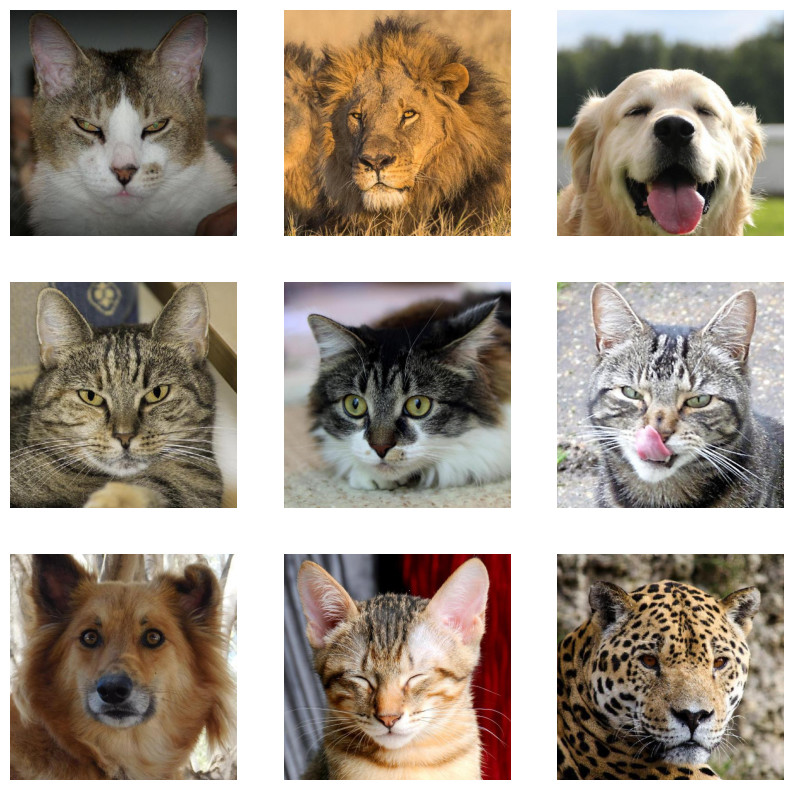

In [77]:
n_rows=3
n_cols=3
fig,axes=plt.subplots(n_rows,n_cols,figsize=(10,10))
for i in range(n_rows):
    for j in range(n_cols):
      image=Image.open(df.sample(n=1)["image_path"].iloc[0]).convert('RGB')
      axes[i,j].imshow(image)
      axes[i,j].axis('off')
plt.show()


In [78]:
LR=1e-4
batch_size=32
epochs=10

In [79]:
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=True)

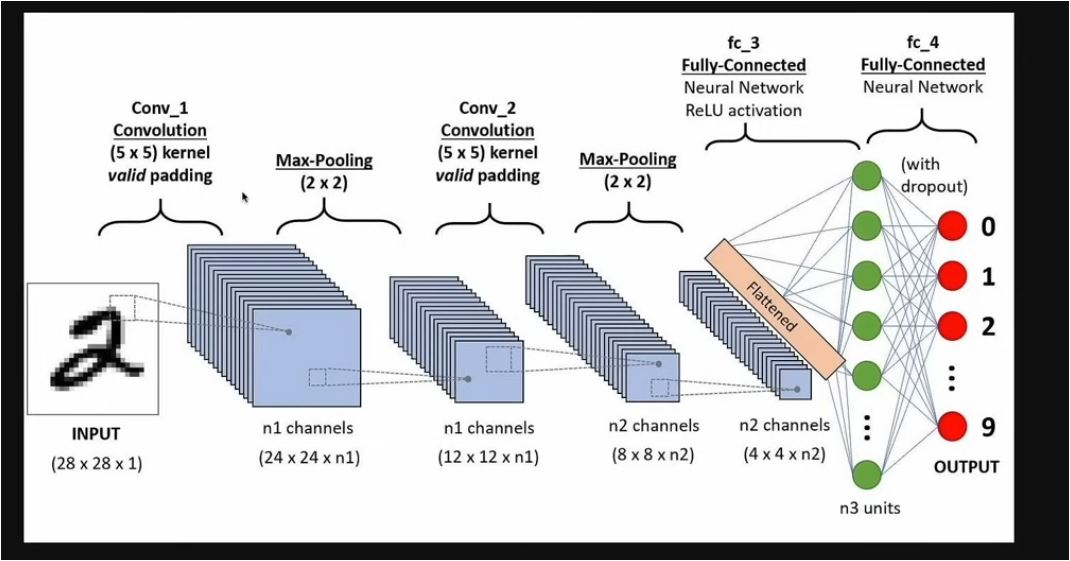

In [80]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1) # First Convolution layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1) # Second Convolution layer
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1) # Third Convolution layer
        self.pooling = nn.MaxPool2d(2,2) # The pooling layer, we will be using the same layer after each conv2d.
        self.relu = nn.ReLU()   # ReLU Activation function

        self.flatten=nn.Flatten()
        self.linear=nn.Linear(128*16*16,128)


        self.output=nn.Linear(128, len(df['labels'].unique())) # Output Linear Layer


    def forward(self, x):
        x = self.conv1(x) # -> Outputs: (32, 128, 128)
        x = self.pooling(x) # -> Outputs: (32, 64, 64)
        x = self.relu(x)

        x = self.conv2(x)  # -> Outputs: (64, 64, 64)
        x = self.pooling(x)  # -> Outputs: (64, 32, 32)
        x = self.relu(x)

        x = self.conv3(x) # -> Outputs: (128, 32, 32)
        x = self.pooling(x) # -> Outputs: (128, 16, 16)
        x = self.relu(x)

        x = self.flatten(x)
        x = self.linear(x)
        x = self.output(x)


        return x





In [81]:
model = Net().to(device)

In [82]:
from torchsummary import summary
summary(model,input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [83]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=LR)

In [84]:

total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(epochs):
    total_loss_train = 0
    total_loss_val = 0
    total_acc_train = 0
    total_acc_val = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(inputs)
        train_loss = criterion(outputs, labels)
        train_loss.backward()
        optimizer.step()

        train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
        total_acc_train += train_acc

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_acc_val += val_acc

    total_loss_train_plot.append(round(total_loss_train / 1000, 4))
    total_loss_validation_plot.append(round(total_loss_val / 1000, 4))
    total_acc_train_plot.append(round(total_acc_train / (train_dataset.__len__()) * 100, 4))
    total_acc_validation_plot.append(round(total_acc_val / (val_dataset.__len__()) * 100, 4))

    print(f'''Epoch {epoch+1}/{epochs}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}
          Validation Loss: {round(total_loss_val/100, 4)} Validation Accuracy: {round((total_acc_val)/val_dataset.__len__() * 100, 4)}''')
    print("="*25)








Epoch 1/10, Train Loss: 0.0 Train Accuracy 77.2297
          Validation Loss: 0.2493 Validation Accuracy: 88.2645
Epoch 2/10, Train Loss: 0.0 Train Accuracy 91.046
          Validation Loss: 0.1587 Validation Accuracy: 92.1074
Epoch 3/10, Train Loss: 0.0 Train Accuracy 93.6232
          Validation Loss: 0.121 Validation Accuracy: 94.0909
Epoch 4/10, Train Loss: 0.0 Train Accuracy 95.12
          Validation Loss: 0.0991 Validation Accuracy: 94.8347
Epoch 5/10, Train Loss: 0.0 Train Accuracy 96.1917
          Validation Loss: 0.0929 Validation Accuracy: 95.124
Epoch 6/10, Train Loss: 0.0 Train Accuracy 97.0065
          Validation Loss: 0.0829 Validation Accuracy: 95.6612
Epoch 7/10, Train Loss: 0.0 Train Accuracy 97.6796
          Validation Loss: 0.0927 Validation Accuracy: 95.4545
Epoch 8/10, Train Loss: 0.0 Train Accuracy 97.9187
          Validation Loss: 0.0803 Validation Accuracy: 95.9917
Epoch 9/10, Train Loss: 0.0 Train Accuracy 98.5121
          Validation Loss: 0.0822 Validati

In [85]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for inputs, labels in test_loader:
    predictions = model(inputs)

    test_acc = (torch.argmax(predictions,axis =1) == labels).sum().item()

    total_acc_test += test_acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()


print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")

Accuracy Score is: 95.8247 and Loss is 0.0115


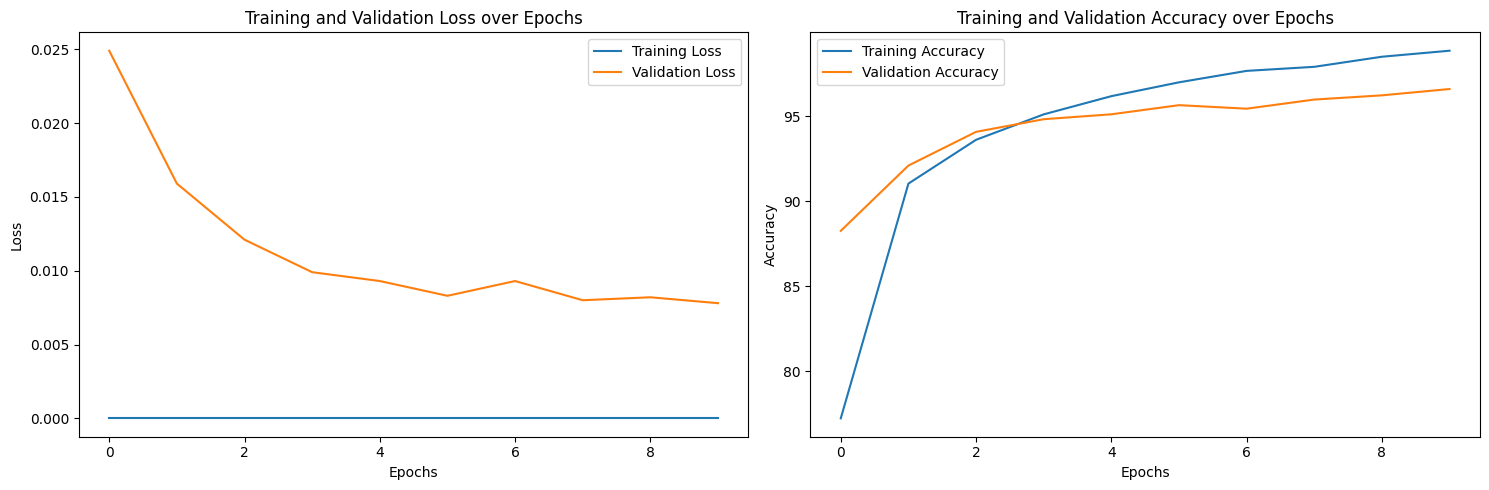

In [86]:

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

plt.show()

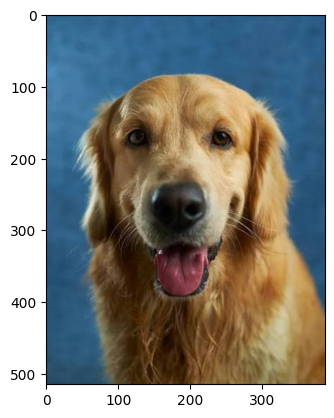

In [93]:
# 1- read image
# 2- Transform using transform object
# 3- predict through the model
# 4- inverse transform by label encoder

def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)

  output = model(image.unsqueeze(0))
  output = torch.argmax(output, axis = 1).item()
  return label_encoder.inverse_transform([output])

## Visualize the image
image = Image.open("/content/images (3).jfif")
plt.imshow(image)
plt.show()





In [94]:
## Predict
print()
print("Prediction: \n")
predict_image("/content/images (3).jfif")


Prediction: 



array(['dog'], dtype=object)